<a href="https://colab.research.google.com/github/Abhhiiissshhek/100_days_of_ML_challenge/blob/main/day-08-model-evaluation/day08_model_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Day 08**

## **Loading Data.....**

In [3]:
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# showing the total no. of missing values in the dataset
df.isnull().sum()

# showing the percentage of missing data
(df.isnull().sum() / len(df)) * 100

# Cabin is 77% missing - basically useless
df.drop('Cabin', axis=1, inplace=True)

# Age is 20% missing - fill with MEDIAN
df['Age'].fillna(df['Age'].median(), inplace=True)

# Embarked is 0.2% missing - fill with MODE
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

df.isnull().sum().sum() # our dataset is clean now !!

# Create Family Size from SibSp + Parch
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Extract Title from Name
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# Create Age Groups
bins = [0, 12, 18, 35, 60, 100]
labels = ['Child', 'Teen', 'Adult', 'Middle-Aged', 'Senior']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

# Create IsAlone flag
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

print(df.head())


<>:28: SyntaxWarning: invalid escape sequence '\.'
<>:28: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipython-input-1424560649.py:28: SyntaxWarning: invalid escape sequence '\.'
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
/tmp/ipython-input-1424560649.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipython-input-1424560649.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment us

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Embarked  FamilySize Title     AgeGroup  \
0      0         A/5 21171   7.2500        S           2    Mr        Adult   
1      0          PC 17599  71.2833        C           2   Mrs  Middle-Aged   
2      0  STON/O2. 3101282   7.9250        S           1  Miss        Adult   
3   

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay


features = ['Pclass', 'Sex', 'Age', 'Fare', 'FamilySize', 'IsAlone']
X = df[features].copy()
y = df['Survived'].values

# Convert Sex to numbers
X['Sex'] = X['Sex'].map({'male': 0, 'female': 1})
X = X.values

print(f"✅ Total samples: {len(X)}")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)


✅ Total samples: 891


#**Day 08**

# **PROBLEM: IMBALANCED DATA**

## **95% ACCURACY = FAKE! 😱**

# **"95% ACCURACY = FAKE! 😱"**

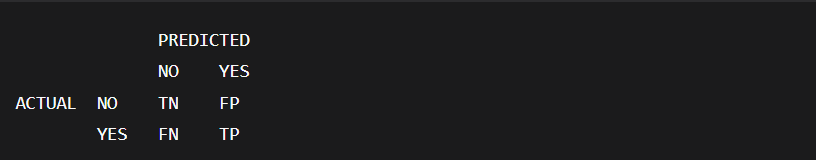

TN (True Negative): ✅ MARA tha, MARA bataya

FP (False Positive): ❌ MARA tha, BACHA bataya

FN (False Negative): ❌ BACHA tha, MARA bataya

TP (True Positive): ✅ BACHA tha, BACHA bataya

## **4 BOXES = FULL STORY 📊**

# **CODE: CONFUSION MATRIX**

In [7]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[90 15]
 [21 53]]


2 lines of code! 90 = sahi MARA, 53 = sahi BACHA. 15+21 = 36 galat.

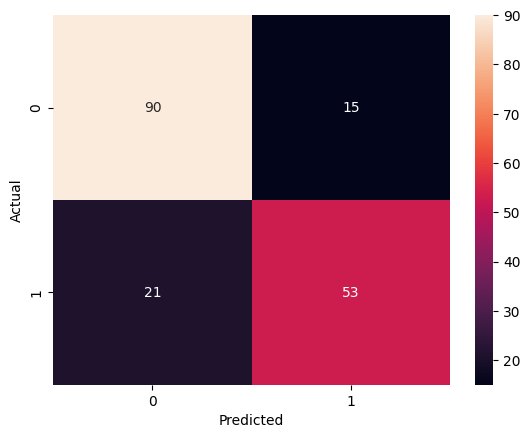

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# **METRICS FROM CONFUSION MATRIX**

Accuracy = (TP + TN) / Total
         = (90 + 53) / 179
         = 143/179 = 79.8% 🤔

WAIT! Ye 75% kyun nahi?

# **CORRECT ACCURACY FORMULA**

## **Check karo - 79.8% accuracy!**
* Mera model pehle se BEHTAR hai

* ✅ TN = 90: MARA tha, MARA bataya
* ✅ TP = 53: BACHA tha, BACHA bataya
* ❌ FP = 15: MARA tha, BACHA bataya
* ❌ FN = 21: BACHA tha, MARA bataya

Accuracy = 79.8% 🎯

# **CONFUSION MATRIX = TRUTH 📈**